In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set style for plots
sns.set_style("whitegrid")

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

print("Feature names:", feature_names)
print("Class names:", class_names)
print("Data shape:", X.shape)
print("Target distribution:\n", pd.Series(y).value_counts())

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: ['setosa' 'versicolor' 'virginica']
Data shape: (150, 4)
Target distribution:
 0    50
1    50
2    50
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 105
Testing samples: 45


In [4]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

y_pred_default = dt_default.predict(X_test)
acc_default = accuracy_score(y_test, y_pred_default)

print(f"Default tree accuracy: {acc_default:.4f}")

Default tree accuracy: 0.9333



Classification Report (Default Tree):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



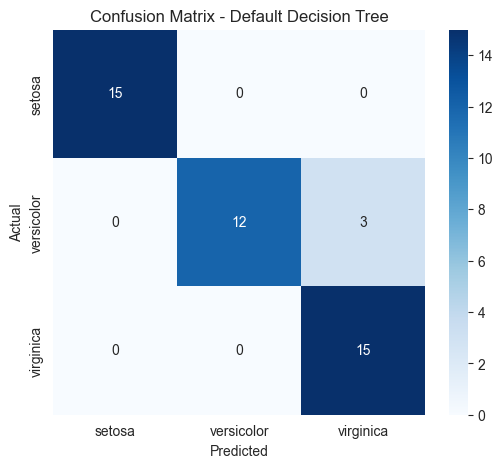

In [5]:
print("\nClassification Report (Default Tree):")
print(classification_report(y_test, y_pred_default, target_names=class_names))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_default)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Default Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

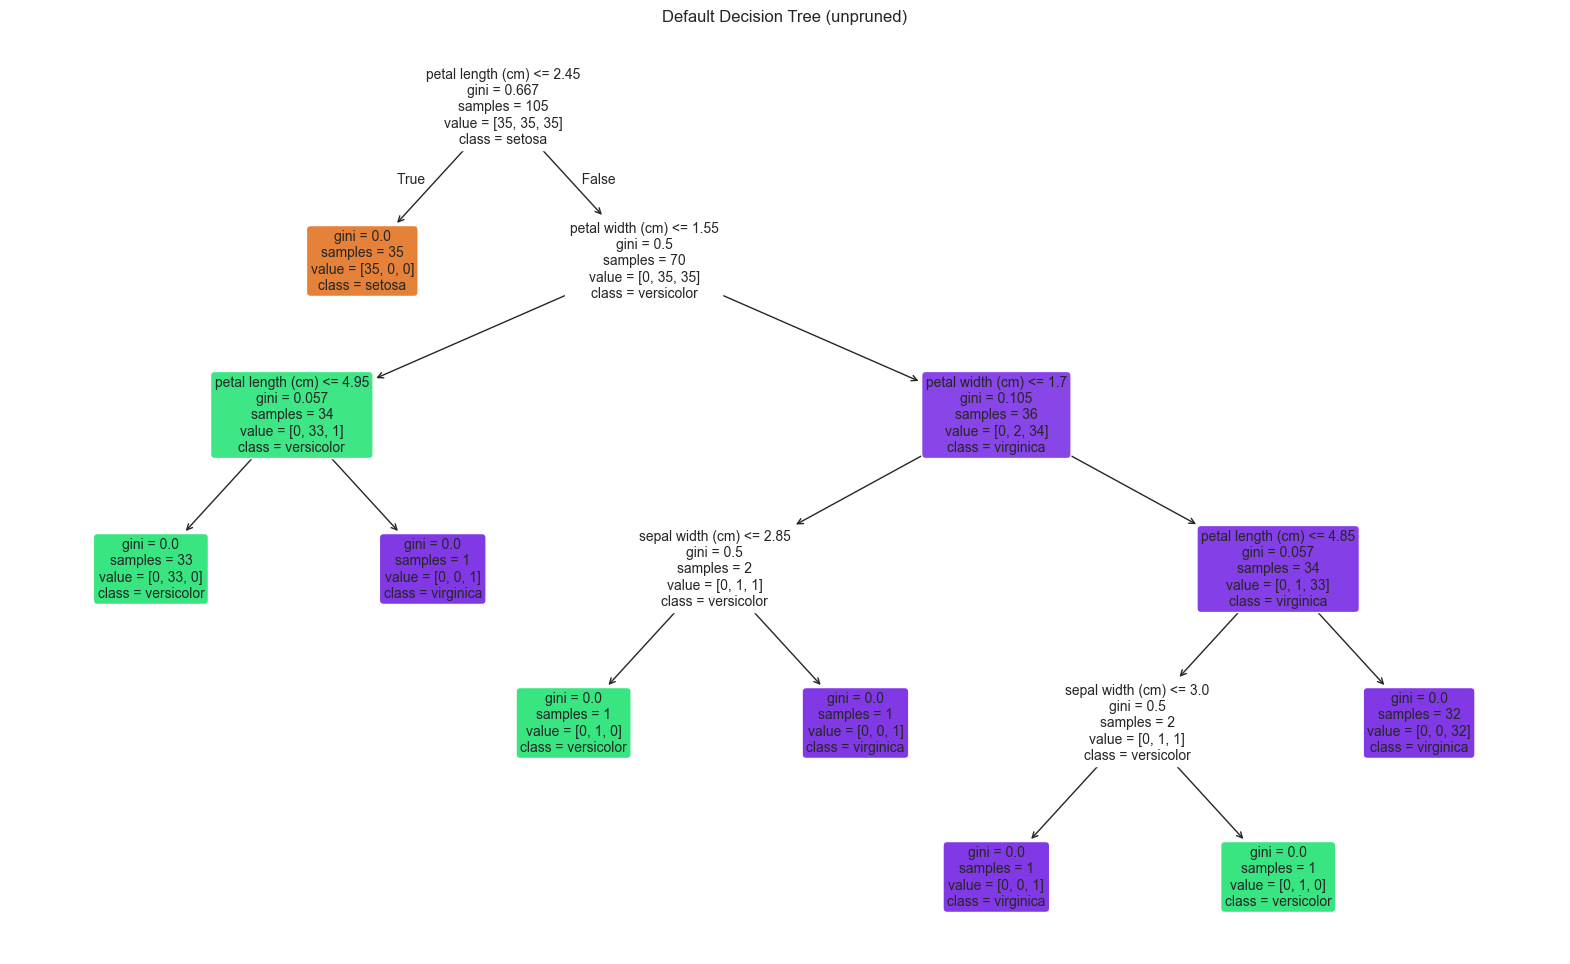

In [6]:
plt.figure(figsize=(20, 12))
plot_tree(dt_default, 
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Default Decision Tree (unpruned)")
plt.show()

Feature importance:
sepal length (cm): 0.0000
sepal width (cm): 0.0286
petal length (cm): 0.5412
petal width (cm): 0.4303


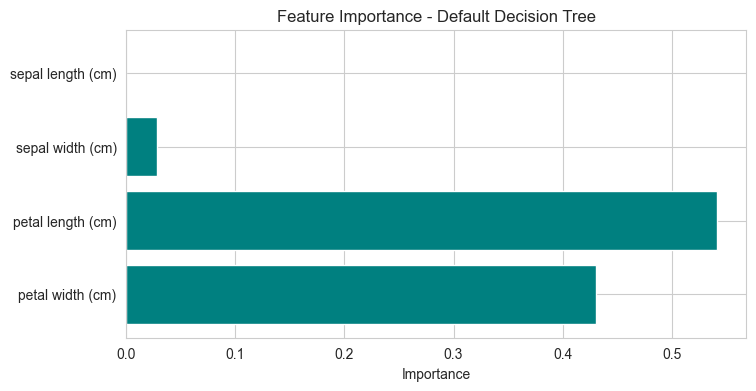

In [7]:
importance = dt_default.feature_importances_

print("Feature importance:")
for name, imp in zip(feature_names, importance):
    print(f"{name}: {imp:.4f}")

# Bar plot
plt.figure(figsize=(8,4))
plt.barh(feature_names, importance, color='teal')
plt.xlabel("Importance")
plt.title("Feature Importance - Default Decision Tree")
plt.gca().invert_yaxis()
plt.show()

Pruned tree (max_depth=3) accuracy: 0.9778


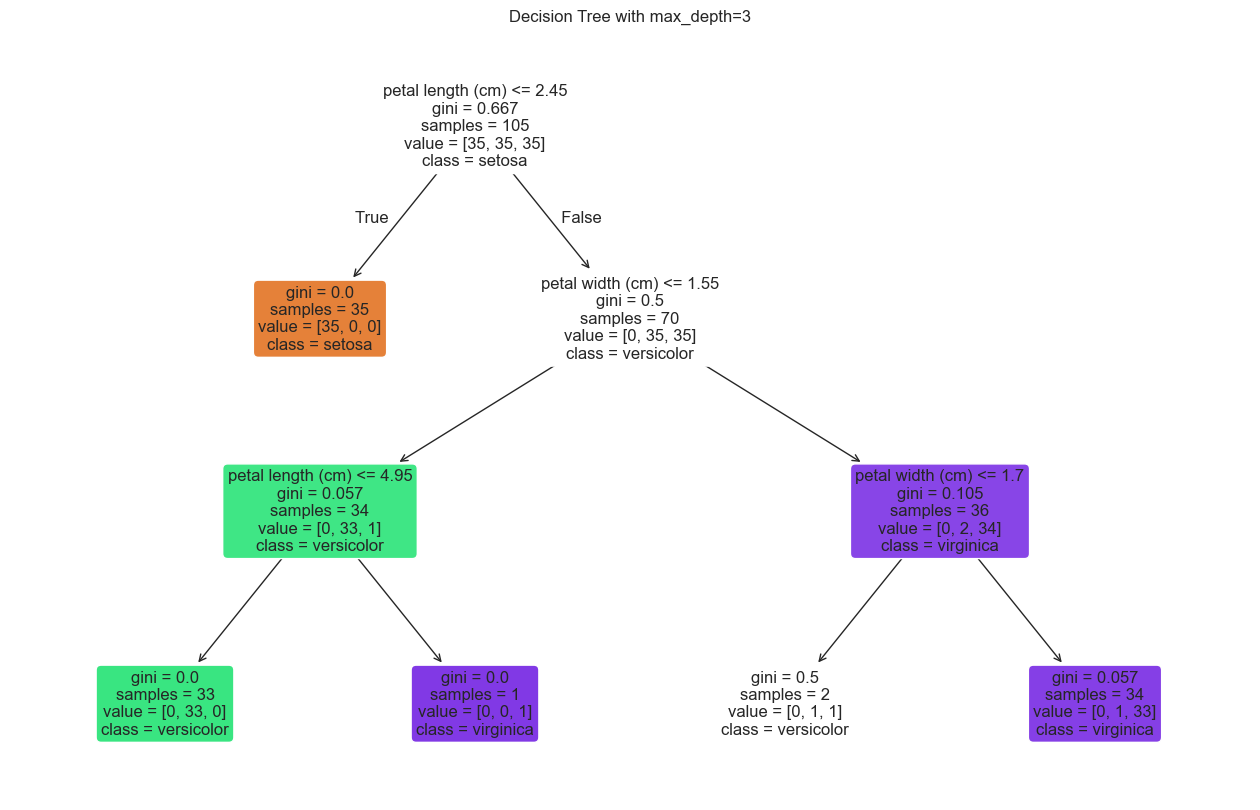

In [8]:
dt_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)
acc_pruned = accuracy_score(y_test, y_pred_pruned)

print(f"Pruned tree (max_depth=3) accuracy: {acc_pruned:.4f}")

# Visualize pruned tree
plt.figure(figsize=(16, 10))
plot_tree(dt_pruned, 
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Decision Tree with max_depth=3")
plt.show()

In [9]:
print("Model Comparison:")
print(f"Default tree - Test accuracy: {acc_default:.4f}")
print(f"Pruned tree (depth=3) - Test accuracy: {acc_pruned:.4f}")

if acc_default == acc_pruned:
    print("Both models have the same accuracy. The pruned tree is simpler and thus preferred.")
elif acc_default > acc_pruned:
    print("Default tree is more accurate but might overfit. Consider cross-validation.")
else:
    print("Pruned tree is more accurate - pruning helped generalization.")

Model Comparison:
Default tree - Test accuracy: 0.9333
Pruned tree (depth=3) - Test accuracy: 0.9778
Pruned tree is more accurate - pruning helped generalization.
